In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules


In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8


In [3]:
basket_df = df[["InvoiceNo", "Description"]]
basket_df.head()


,InvoiceNo,Description
0,536365,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,WHITE METAL LANTERN
2,536365,CREAM CUPID HEARTS COAT HANGER
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,RED WOOLLY HOTTIE WHITE HEART.


In [4]:
basket_df = basket_df.drop_duplicates()
basket_df.shape


(387772, 2)

In [5]:
basket = (
    basket_df
    .groupby(["InvoiceNo", "Description"])["Description"]
    .count()
    .unstack()
    .fillna(0)
)


In [6]:
basket = basket.apply(lambda col: col.map(lambda x: 1 if x > 0 else 0))


basket.head()


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
product_support = basket.mean()
frequent_products = product_support[product_support > 0.01].index

basket = basket[frequent_products]
basket.shape


(18536, 620)

In [8]:
basket_bool = basket.astype(bool)
frequent_itemsets = apriori(
    basket_bool,
    min_support=0.02,
    use_colnames=True
)
frequent_itemsets.head()


,support,itemsets
0,0.021688,(3 STRIPEY MICE FELTCRAFT)
1,0.039167,(6 RIBBONS RUSTIC CHARM)
2,0.025140,(60 CAKE CASES VINTAGE CHRISTMAS)
3,0.035445,(60 TEATIME FAIRY CAKE CASES)
4,0.027028,(72 SWEETHEART FAIRY CAKE CASES)


In [9]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035
1,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
2,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.047313,0.033071,0.021364,0.451539,13.653725,1.0,0.019799,1.762987,0.972786,0.361974,0.432781,0.548771
3,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.033071,0.047313,0.021364,0.646003,13.653725,1.0,0.019799,2.691230,0.958457,0.361974,0.628423,0.548771
4,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.033233,0.037980,0.022874,0.688312,18.122934,1.0,0.021612,3.086480,0.977300,0.473214,0.676006,0.645292


In [10]:
rules_sorted = rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

rules_sorted.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
71,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.029186,0.029996,0.021040,0.720887,24.033032,1.0,0.020165,3.475313,0.987204,0.551627,0.712256,0.711163
74,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.029996,0.029186,0.021040,0.701439,24.033032,1.0,0.020165,3.251641,0.988027,0.551627,0.692463,0.711163
70,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.023522,0.037279,0.021040,0.894495,23.994742,1.0,0.020163,9.124923,0.981409,0.529172,0.890410,0.729447
75,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.037279,0.023522,0.021040,0.564399,23.994742,1.0,0.020163,2.241683,0.995433,0.529172,0.553907,0.729447
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.029996,0.037279,0.024817,0.827338,22.193256,1.0,0.023698,5.575760,0.984471,0.584498,0.820652,0.746520
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037279,0.029996,0.024817,0.665702,22.193256,1.0,0.023698,2.901615,0.991919,0.584498,0.655364,0.746520
72,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.024817,0.042242,0.021040,0.847826,20.070631,1.0,0.019992,6.293837,0.974356,0.457210,0.841114,0.672955
73,(ROSES REGENCY TEACUP AND SAUCER ),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.042242,0.024817,0.021040,0.498084,20.070631,1.0,0.019992,1.942923,0.992084,0.457210,0.485311,0.672955
63,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.029996,0.042242,0.023522,0.784173,18.563760,1.0,0.022255,4.437611,0.975389,0.482835,0.774654,0.670503
62,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.042242,0.029996,0.023522,0.556833,18.563760,1.0,0.022255,2.188799,0.987861,0.482835,0.543129,0.670503


In [11]:
rules_final = rules_sorted[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

rules_final.head()


,antecedents,consequents,support,confidence,lift
71,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.021040,0.720887,24.033032
74,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.021040,0.701439,24.033032
70,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.021040,0.894495,23.994742
75,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.021040,0.564399,23.994742
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024817,0.827338,22.193256


In [12]:

rules_final = rules_final.copy()


rules_final.loc[:, "antecedents"] = rules_final["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_final.loc[:, "consequents"] = rules_final["consequents"].apply(lambda x: ", ".join(list(x)))


rules_final.head()


,antecedents,consequents,support,confidence,lift
71,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",PINK REGENCY TEACUP AND SAUCER,0.021040,0.720887,24.033032
74,PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , GREEN REGENC...",0.021040,0.701439,24.033032
70,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",GREEN REGENCY TEACUP AND SAUCER,0.021040,0.894495,23.994742
75,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",0.021040,0.564399,23.994742
8,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024817,0.827338,22.193256


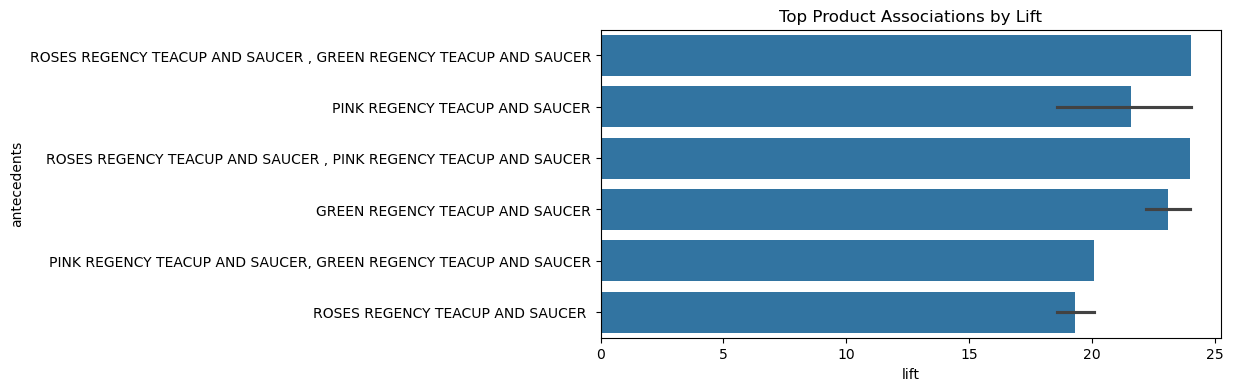

In [13]:
top_rules = rules_final.head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    x="lift",
    y="antecedents",
    data=top_rules
)
plt.title("Top Product Associations by Lift")
plt.show()


In [14]:
rules_final.to_csv("../data/association_rules.csv", index=False)

print("✅ Association rules saved successfully")


✅ Association rules saved successfully
